In [256]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

print("All required libraries imported successfully!")

All required libraries imported successfully!


In [257]:
df = pd.read_csv("train.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (891, 12)


In [258]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [259]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [260]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [261]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

print("Missing value percentage:")
print(missing_percentage[missing_percentage > 0])

Missing value percentage:
Age         19.865320
Cabin       77.104377
Embarked     0.224467
dtype: float64


In [262]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [263]:
# Fill missing Age values with the median
df["Age"] = df["Age"].fillna(df["Age"].median())

# Fill missing Cabin values with "Unknown"
df["Cabin"] = df["Cabin"].fillna("Unknown")

# Fill missing Embarked values with the mode
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

print("Missing values handled successfully!")

Missing values handled successfully!


In [264]:
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64


In [265]:
# Select important columns for analysis
selected_data = df[["Survived", "Pclass", "Sex", "Age", "Fare"]]

selected_data.head()

,Survived,Pclass,Sex,Age,Fare
0,0,3,male,22.0,7.2500
1,1,1,female,38.0,71.2833
2,1,3,female,26.0,7.9250
3,1,1,female,35.0,53.1000
4,0,3,male,35.0,8.0500


In [266]:
female_passengers = df[df["Sex"] == "female"]

print("Number of female passengers:", len(female_passengers))
female_passengers.head()

Number of female passengers: 314


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Unknown,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,Unknown,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,Unknown,C


In [267]:
# Sort passengers by fare from highest to lowest
sorted_fare = df.sort_values(by="Fare", ascending=False)

sorted_fare[["PassengerId", "Name", "Pclass", "Fare"]].head(10)

,PassengerId,Name,Pclass,Fare
679,680,"Cardeza, Mr. Thomas Drake Martinez",1,512.3292
258,259,"Ward, Miss. Anna",1,512.3292
737,738,"Lesurer, Mr. Gustave J",1,512.3292
88,89,"Fortune, Miss. Mabel Helen",1,263.0000
438,439,"Fortune, Mr. Mark",1,263.0000
341,342,"Fortune, Miss. Alice Elizabeth",1,263.0000
27,28,"Fortune, Mr. Charles Alexander",1,263.0000
742,743,"Ryerson, Miss. Susan Parker ""Suzette""",1,262.3750
311,312,"Ryerson, Miss. Emily Borie",1,262.3750
299,300,"Baxter, Mrs. James (Helene DeLaudeniere Chaput)",1,247.5208


In [268]:
class_analysis = df.groupby("Pclass").agg(
    Average_Survival_Rate=("Survived", "mean"),
    Average_Fare=("Fare", "mean"),
    Passenger_Count=("PassengerId", "count")
)

class_analysis

,Average_Survival_Rate,Average_Fare,Passenger_Count
Pclass,,,
1,0.629630,84.154687,216
2,0.472826,20.662183,184
3,0.242363,13.675550,491


In [269]:
fare_array = np.array(df["Fare"])

print("Average Fare:", np.mean(fare_array))
print("Minimum Fare:", np.min(fare_array))
print("Maximum Fare:", np.max(fare_array))
print("Fare Standard Deviation:", np.std(fare_array))

Average Fare: 32.204207968574636
Minimum Fare: 0.0
Maximum Fare: 512.3292
Fare Standard Deviation: 49.6655344447741


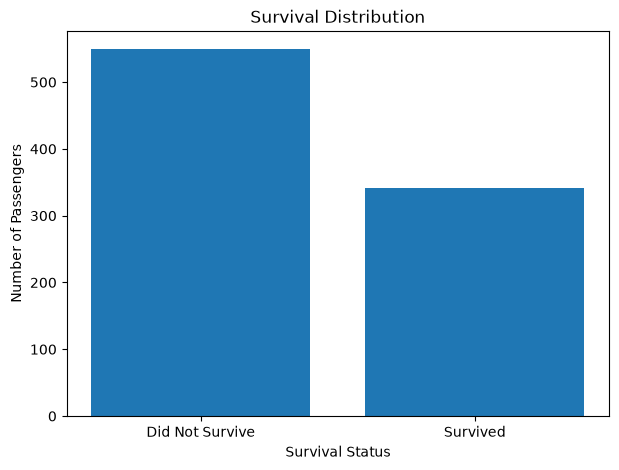

In [270]:
survival_counts = df["Survived"].value_counts().sort_index()

plt.figure(figsize=(7, 5))
plt.bar(
    ["Did Not Survive", "Survived"],
    survival_counts.values
)

plt.title("Survival Distribution")
plt.xlabel("Survival Status")
plt.ylabel("Number of Passengers")
plt.show()

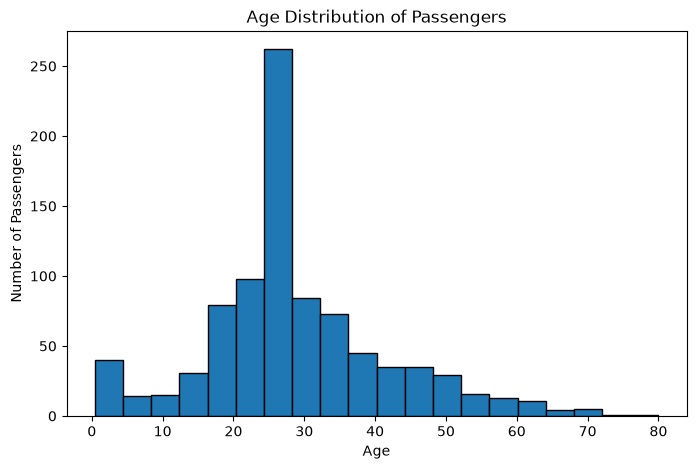

In [271]:
plt.figure(figsize=(8, 5))

plt.hist(df["Age"], bins=20, edgecolor="black")

plt.title("Age Distribution of Passengers")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

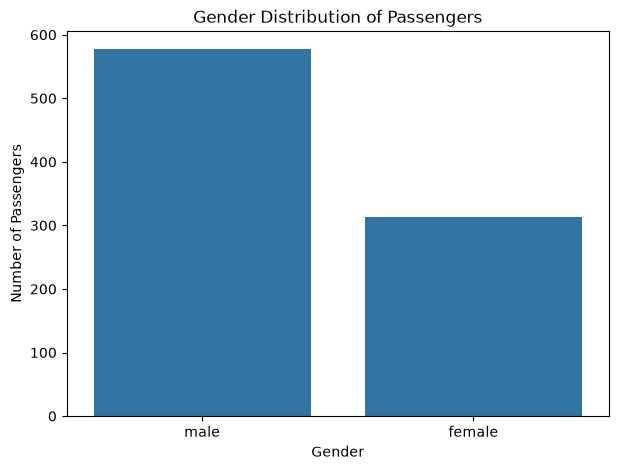

In [272]:
plt.figure(figsize=(7, 5))

sns.countplot(x="Sex", data=df)

plt.title("Gender Distribution of Passengers")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")

plt.show()

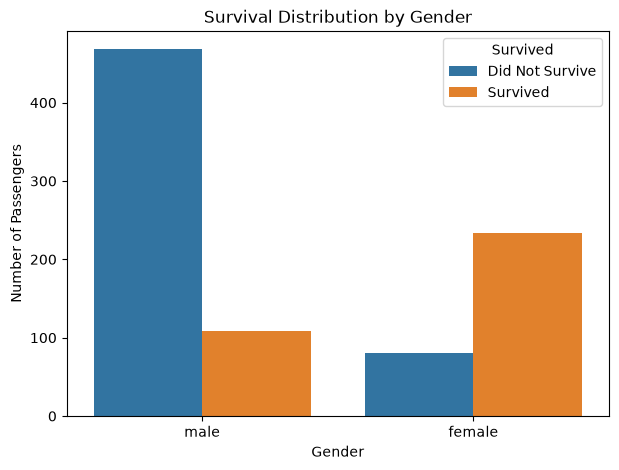

In [273]:
plt.figure(figsize=(7, 5))

sns.countplot(x="Sex", hue="Survived", data=df)

plt.title("Survival Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")
plt.legend(title="Survived", labels=["Did Not Survive", "Survived"])

plt.show()

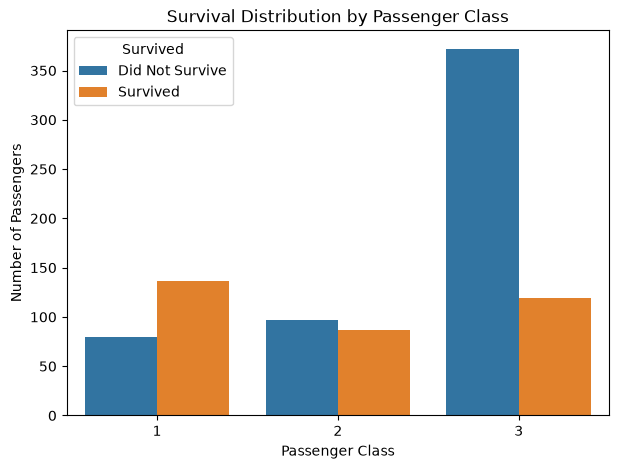

In [274]:
plt.figure(figsize=(7, 5))

sns.countplot(x="Pclass", hue="Survived", data=df)

plt.title("Survival Distribution by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.legend(title="Survived", labels=["Did Not Survive", "Survived"])

plt.show()

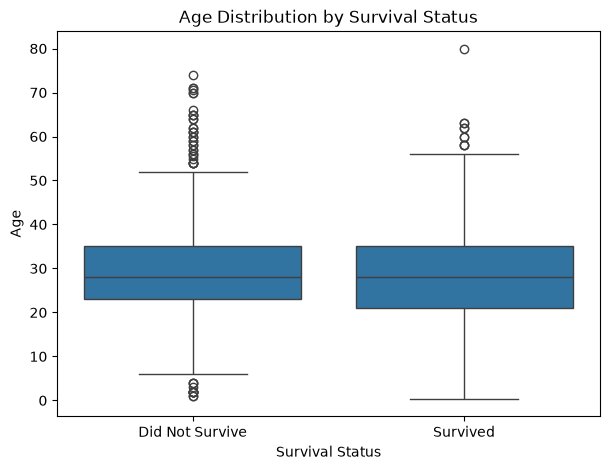

In [275]:
plt.figure(figsize=(7, 5))

sns.boxplot(x="Survived", y="Age", data=df)

plt.title("Age Distribution by Survival Status")
plt.xlabel("Survival Status")
plt.ylabel("Age")
plt.xticks([0, 1], ["Did Not Survive", "Survived"])

plt.show()

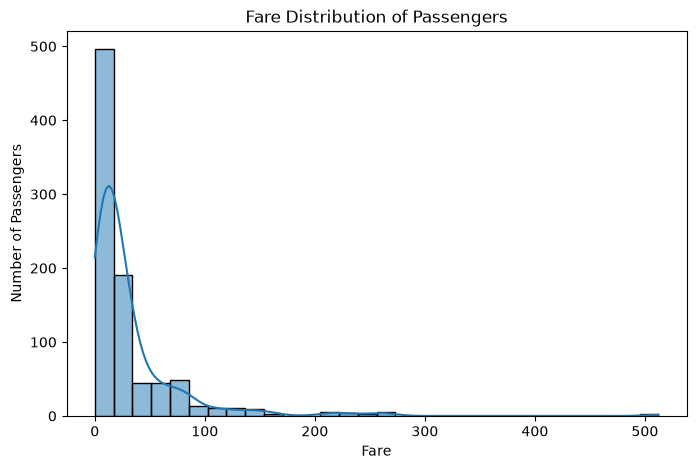

In [276]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Fare"], bins=30, kde=True)

plt.title("Fare Distribution of Passengers")
plt.xlabel("Fare")
plt.ylabel("Number of Passengers")

plt.show()

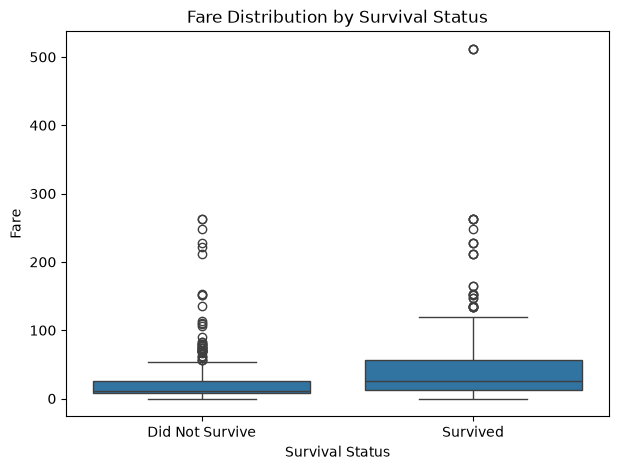

In [277]:
plt.figure(figsize=(7, 5))

sns.boxplot(x="Survived", y="Fare", data=df)

plt.title("Fare Distribution by Survival Status")
plt.xlabel("Survival Status")
plt.ylabel("Fare")
plt.xticks([0, 1], ["Did Not Survive", "Survived"])

plt.show()

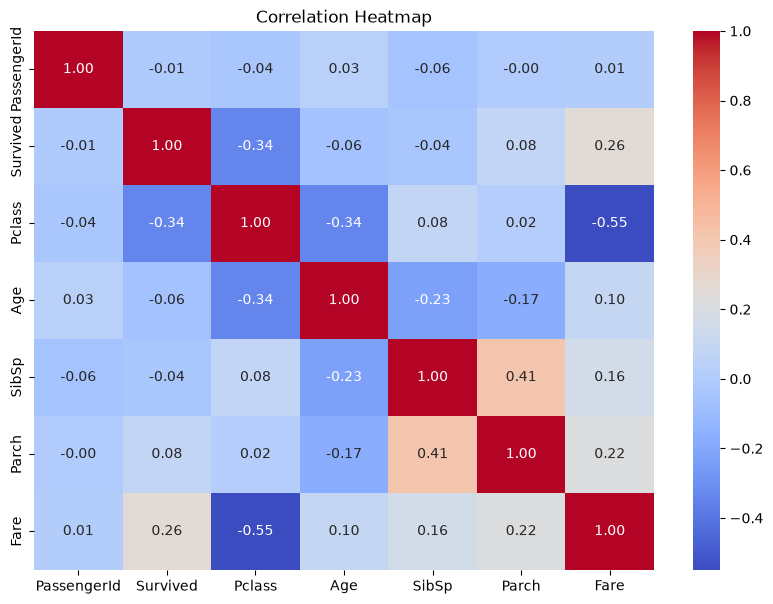

In [278]:
plt.figure(figsize=(10, 7))

correlation = df.select_dtypes(include="number").corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()